# Fixed-Point Cast — Runtime Benchmark

Benchmark the Triton `float_to_fixed` and `fixed_to_float` kernels across vector sizes and dtype combinations.

Timing uses `triton.testing.do_bench` (GPU-side median).

In [8]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))
sys.path.insert(0, os.path.abspath("../../tests/triton_kernels"))

import numpy as np
import torch
import triton
import triton.language as tl
import matplotlib.pyplot as plt

from fixed_point_helpers import f2x, x2f

In [9]:
SIZES = [2**e for e in range(6, 9)]  # 64 … 131072

# (label, input_dtype, output_dtype, frac_bits)
F2X_CONFIGS = [
    ("fp16 → int16",  torch.float16, torch.int16,  8),
    ("fp16 → int32",  torch.float16, torch.int32, 16),
    ("fp16 → int64",  torch.float16, torch.int64, 32),
    ("fp32 → int32",  torch.float32, torch.int32, 16),
    ("fp32 → int64",  torch.float32, torch.int64, 32),
    ("fp64 → int64",  torch.float64, torch.int64, 32),
]

X2F_CONFIGS = [
    ("int16 → fp16",  torch.int16,  torch.float16,  8),
    ("int32 → fp16",  torch.int32,  torch.float16, 16),
    ("int64 → fp16",  torch.int64,  torch.float16, 32),
    ("int32 → fp32",  torch.int32,  torch.float32, 16),
    ("int64 → fp32",  torch.int64,  torch.float32, 32),
    ("int64 → fp64",  torch.int64,  torch.float64, 32),
]

# ── visual style: colour by int bitwidth, linestyle by float bitwidth ─
BITWIDTH_COLORS = {16: "#e41a1c", 32: "#377eb8", 64: "#4daf4a"}
FLOAT_STYLE = {16: "-", 32: "--", 64: ":"}


def _parse_style(label, direction):
    """Return (color, linestyle) for a cast label like 'fp16 → int32'."""
    import re
    nums = [int(x) for x in re.findall(r"\d+", label)]
    if direction == "f2x":
        float_bits, int_bits = nums
    else:
        int_bits, float_bits = nums
    return BITWIDTH_COLORS[int_bits], FLOAT_STYLE[float_bits]


def bench_f2x():
    results = {}
    for label, in_dt, out_dt, frac in F2X_CONFIGS:
        times = []
        for n in SIZES:
            x = torch.randn(n, device="cuda", dtype=in_dt)
            f2x(x, frac, out_dt)  # warm-up / compile
            ms = triton.testing.do_bench(lambda: f2x(x, frac, out_dt), warmup=100, rep=500)
            times.append(ms * 1e3)  # us
        results[label] = times
    return results


def bench_x2f():
    results = {}
    for label, in_dt, out_dt, frac in X2F_CONFIGS:
        times = []
        for n in SIZES:
            x = torch.randint(-1000, 1000, (n,), device="cuda", dtype=in_dt)
            x2f(x, frac, out_dt)  # warm-up / compile
            ms = triton.testing.do_bench(lambda: x2f(x, frac, out_dt), warmup=100, rep=500)
            times.append(ms * 1e3)
        results[label] = times
    return results


f2x_results = bench_f2x()
x2f_results = bench_x2f()

## float_to_fixed runtime

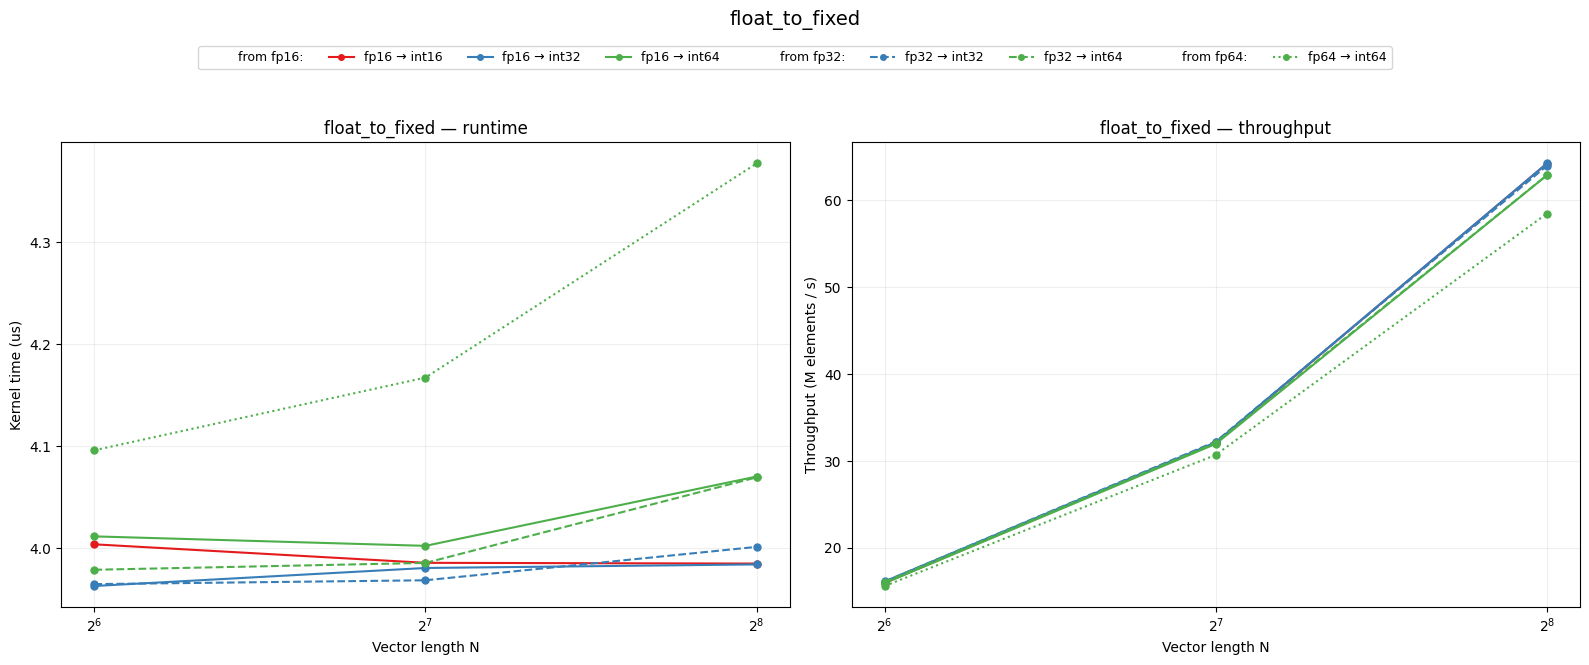

In [ ]:
from matplotlib.lines import Line2D

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for label, times in f2x_results.items():
    color, ls = _parse_style(label, "f2x")
    ax1.plot(SIZES, times, marker="o", markersize=5, color=color, linestyle=ls, label=label)
ax1.set_xscale("log", base=2)
ax1.set_xlabel("Vector length N")
ax1.set_ylabel("Kernel time (us)")
ax1.set_title("float_to_fixed — runtime")
ax1.grid(True, alpha=0.2)

for label, times in f2x_results.items():
    color, ls = _parse_style(label, "f2x")
    tp = np.array(SIZES) / np.array(times)
    ax2.plot(SIZES, tp, marker="o", markersize=5, color=color, linestyle=ls, label=label)
ax2.set_xscale("log", base=2)
ax2.set_xlabel("Vector length N")
ax2.set_ylabel("Throughput (M elements / s)")
ax2.set_title("float_to_fixed — throughput")
ax2.grid(True, alpha=0.2)

legend_handles = []
for fp_bits, fp_label in [(16, "from fp16"), (32, "from fp32"), (64, "from fp64")]:
    legend_handles.append(Line2D([], [], color="none", label=f"{fp_label}:"))
    for label in f2x_results:
        color, ls = _parse_style(label, "f2x")
        if ls == FLOAT_STYLE[fp_bits]:
            legend_handles.append(Line2D([], [], color=color, linestyle=ls,
                                         marker="o", markersize=4, label=label))

fig.legend(handles=legend_handles, loc="upper center",
           ncol=len(f2x_results) + 3, bbox_to_anchor=(0.5, 1.05), fontsize=9)
fig.suptitle("float_to_fixed", fontsize=14, y=1.10)
plt.tight_layout()
plt.show()

## fixed_to_float runtime

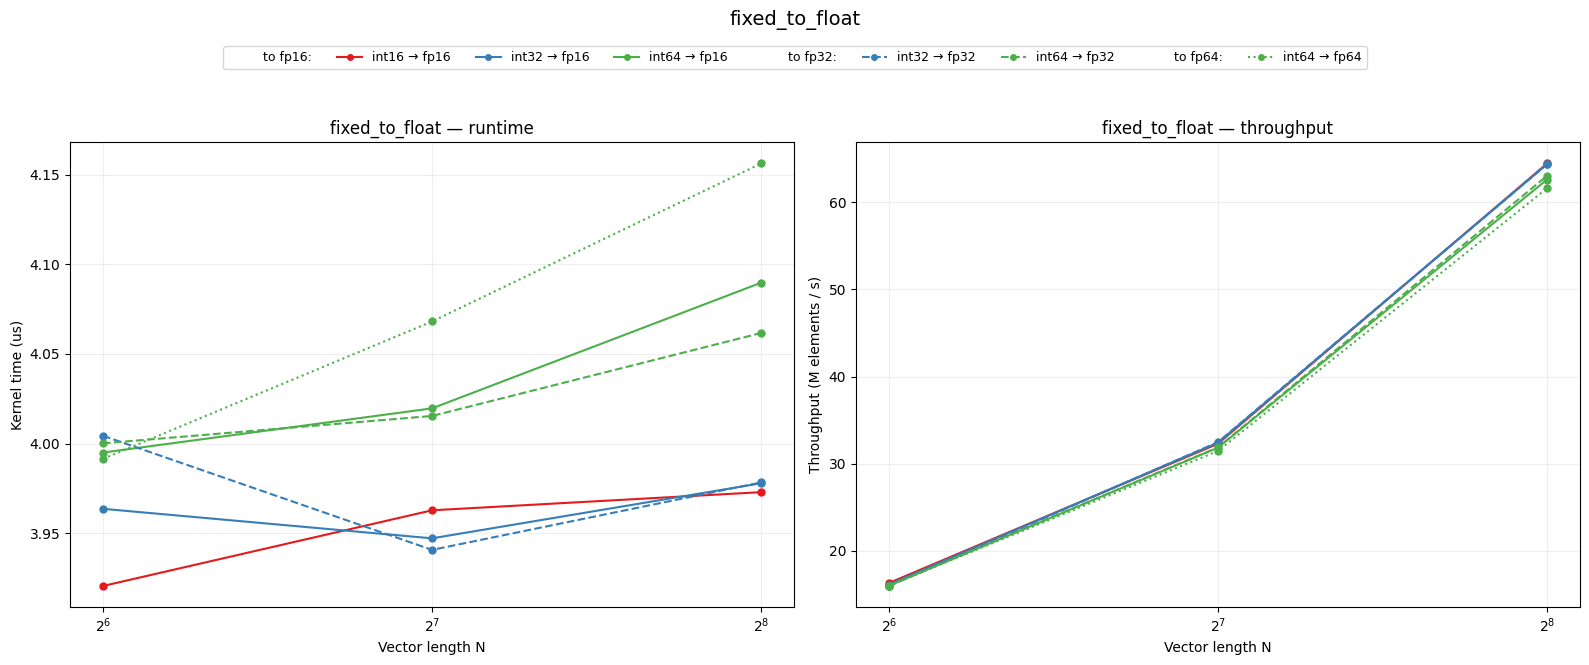

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for label, times in x2f_results.items():
    color, ls = _parse_style(label, "x2f")
    ax1.plot(SIZES, times, marker="o", markersize=5, color=color, linestyle=ls, label=label)
ax1.set_xscale("log", base=2)
ax1.set_xlabel("Vector length N")
ax1.set_ylabel("Kernel time (us)")
ax1.set_title("fixed_to_float — runtime")
ax1.grid(True, alpha=0.2)

for label, times in x2f_results.items():
    color, ls = _parse_style(label, "x2f")
    tp = np.array(SIZES) / np.array(times)
    ax2.plot(SIZES, tp, marker="o", markersize=5, color=color, linestyle=ls, label=label)
ax2.set_xscale("log", base=2)
ax2.set_xlabel("Vector length N")
ax2.set_ylabel("Throughput (M elements / s)")
ax2.set_title("fixed_to_float — throughput")
ax2.grid(True, alpha=0.2)

legend_handles = []
for fp_bits, fp_label in [(16, "to fp16"), (32, "to fp32"), (64, "to fp64")]:
    legend_handles.append(Line2D([], [], color="none", label=f"{fp_label}:"))
    for label in x2f_results:
        color, ls = _parse_style(label, "x2f")
        if ls == FLOAT_STYLE[fp_bits]:
            legend_handles.append(Line2D([], [], color=color, linestyle=ls,
                                         marker="o", markersize=4, label=label))

fig.legend(handles=legend_handles, loc="upper center",
           ncol=len(x2f_results) + 3, bbox_to_anchor=(0.5, 1.05), fontsize=9)
fig.suptitle("fixed_to_float", fontsize=14, y=1.10)
plt.tight_layout()
plt.show()

## Summary tables (N = 131072)

In [12]:
def print_table(title, results):
    print(title)
    print(f"  {'Cast':<18} {'Time (us)':>10} {'Throughput (M el/s)':>20}")
    print("  " + "-" * 50)
    for label, times in results.items():
        us = times[-1]
        tp = SIZES[-1] / us
        print(f"  {label:<18} {us:10.2f} {tp:20.1f}")
    print()

print_table("float_to_fixed", f2x_results)
print_table("fixed_to_float", x2f_results)

float_to_fixed
  Cast                Time (us)  Throughput (M el/s)
  --------------------------------------------------
  fp16 → int16             3.99                 64.2
  fp16 → int32             3.98                 64.3
  fp16 → int64             4.07                 62.9
  fp32 → int32             4.00                 64.0
  fp32 → int64             4.07                 62.9
  fp64 → int64             4.38                 58.5

fixed_to_float
  Cast                Time (us)  Throughput (M el/s)
  --------------------------------------------------
  int16 → fp16             3.97                 64.4
  int32 → fp16             3.98                 64.4
  int64 → fp16             4.09                 62.6
  int32 → fp32             3.98                 64.3
  int64 → fp32             4.06                 63.0
  int64 → fp64             4.16                 61.6

